In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
df = pd.read_csv("../data/raw/train.csv")

df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## Initial Observations

- The dataset contains five columns.
- `text` contains the tweet that will be used for prediction.
- `target` is the binary label.
- `keyword` and `location` contain missing values.
- `id` appears to be a unique identifier and is unlikely to be useful for training.

In [3]:
df.shape

(7613, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


### Observations

- Dataset contains 7,613 tweets.
- The dataset has 5 columns.
- `text` and `target` have no missing values.
- `keyword` contains a small number of missing values.
- `location` contains many missing values.
- `keyword` and `location` may require preprocessing or may be excluded depending on their usefulness.

In [5]:
df.describe(include="all")

,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of Toddler: Report: An 11-year-old boy has been charged with manslaughter over the fatal sh...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


### Why use `describe(include="all")`?

The dataset contains both numeric and text columns.

Using `include="all"` allows us to inspect:

- Numeric statistics
- Number of unique text values
- Most frequent text values
- Frequency of the most common values

In [6]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

### Missing Values Analysis

- `id` has no missing values.
- `text` has no missing values.
- `target` has no missing values.
- `keyword` contains a small number of missing values.
- `location` contains a significant number of missing values.
- Since our primary feature is the tweet text, missing values in `location` are not immediately critical.

In [7]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records

Duplicate rows were checked to ensure data quality.

Duplicate records can bias the training process by giving repeated importance to identical observations.

If duplicates are present, they will be removed during preprocessing.

**Observation:**
- No duplicate records were found in the dataset.
- Therefore, no duplicate removal is required during preprocessing.

In [8]:
df["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [9]:
df["target"].value_counts(normalize=True).round(3)

target
0    0.57
1    0.43
Name: proportion, dtype: float64

## Target Variable Distribution

The target column represents the class label:

- **0** → Non-disaster tweet
- **1** → Disaster-related tweet

The class distribution was analyzed to determine whether the dataset is balanced.

A balanced dataset helps prevent the model from becoming biased toward the majority class.

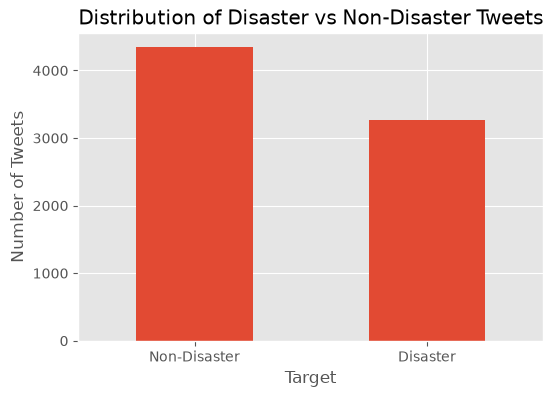

In [10]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Disaster vs Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks([0,1], ["Non-Disaster", "Disaster"], rotation=0)

plt.show()

## Target Distribution

### Observation

- The dataset contains both disaster and non-disaster tweets.
- Approximately 57% of the tweets belong to the non-disaster class.
- Approximately 43% belong to the disaster class.
- The dataset is reasonably balanced, making it suitable for supervised binary classification without requiring major class balancing techniques.

In [11]:
df["text_length"] = df["text"].str.len()

df[["text", "text_length"]].head()

,text,text_length
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,133
3,"13,000 people receive #wildfires evacuation orders in California",65
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,88


In [12]:
df["text_length"].describe()

count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: text_length, dtype: float64

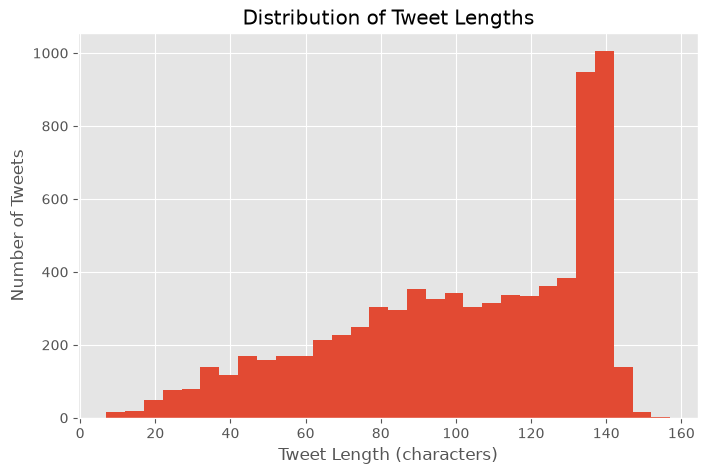

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=30)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Number of Tweets")

plt.show()

## Tweet Length Analysis

### Observation

- Tweet lengths vary across the dataset.
- Most tweets are relatively short.
- A smaller number of tweets are significantly longer.
- No empty tweets were observed because the `text` column has no missing values.

In [14]:
df.groupby("target")["text_length"].mean()

target
0     95.706817
1    108.113421
Name: text_length, dtype: float64

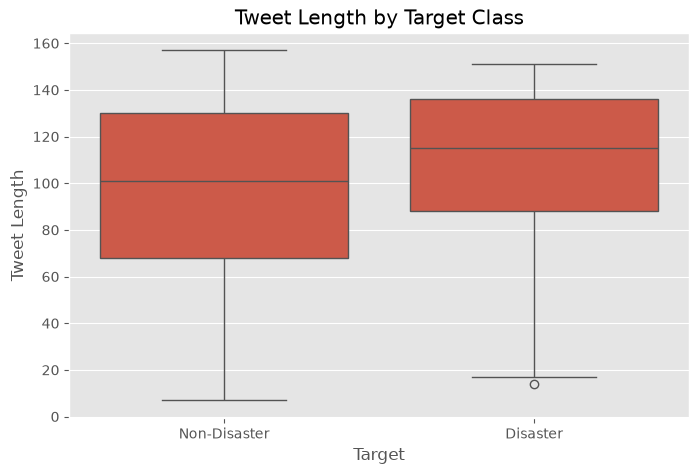

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="text_length"
)

plt.title("Tweet Length by Target Class")

plt.xlabel("Target")

plt.ylabel("Tweet Length")

plt.xticks([0,1],["Non-Disaster","Disaster"])

plt.show()

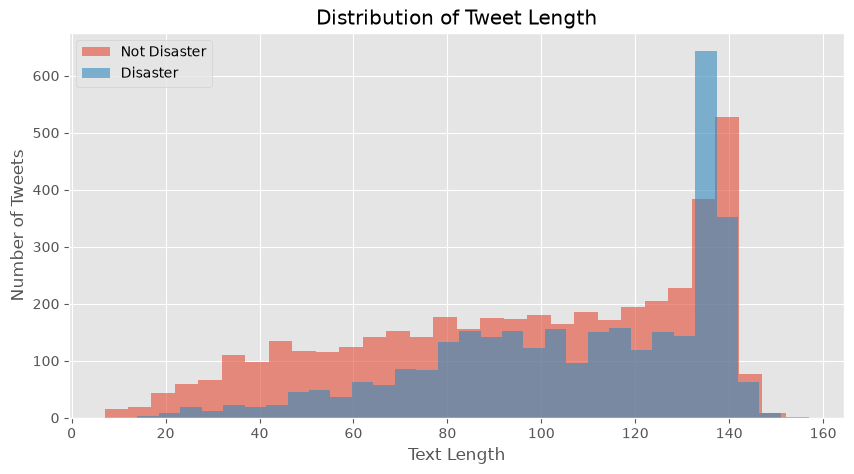

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df[df["target"] == 0]["text_length"],
         bins=30,
         alpha=0.6,
         label="Not Disaster")

plt.hist(df[df["target"] == 1]["text_length"],
         bins=30,
         alpha=0.6,
         label="Disaster")

plt.xlabel("Text Length")
plt.ylabel("Number of Tweets")
plt.title("Distribution of Tweet Length")
plt.legend()
plt.show()

### Observation

- Disaster-related tweets have a slightly higher average text length than non-disaster tweets.
- Most tweets in both classes are concentrated near the 140-character limit.
- There is significant overlap between the two distributions.
- Therefore, text length alone is not sufficient for classification, but it can be a useful additional feature when combined with textual features.

In [17]:

from collections import Counter

# Create one large string containing all disaster tweets
# astype(str) ensures all values are treated as strings
# " ".join(...) combines all tweets into one long sentence
disaster_text = " ".join(df[df["target"] == 1]["text"].astype(str))

# Split the long sentence into individual words
disaster_words = disaster_text.split()

# Count how many times each word appears
word_counts = Counter(disaster_words)

# Display the 20 most common words
word_counts.most_common(20)

[('the', 1051),
 ('in', 1037),
 ('of', 888),
 ('a', 730),
 ('to', 706),
 ('and', 462),
 ('-', 389),
 ('on', 386),
 ('for', 368),
 ('is', 302),
 ('at', 273),
 ('I', 259),
 ('The', 257),
 ('by', 244),
 ('from', 206),
 ('A', 167),
 ('that', 166),
 ('with', 159),
 ('was', 158),
 ('are', 150)]

In [18]:
# Display one sample disaster tweet before preprocessing
print("Original Tweet:\n")
print(df[df["target"] == 1]["text"].iloc[0])

Original Tweet:

Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all


In [19]:
# Convert the sample tweet to lowercase
sample = df[df["target"] == 1]["text"].iloc[0]

print("Original:\n")
print(sample)

print("\nLowercase:\n")
print(sample.lower())

Original:

Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Lowercase:

our deeds are the reason of this #earthquake may allah forgive us all


In [20]:
# Import Python's built-in string module
# It contains a constant called 'punctuation'
import string

# Show all punctuation characters available in Python
print("Punctuation Characters:")
print(string.punctuation)

# Remove punctuation from the sample tweet
clean_text = sample.lower()

# Replace every punctuation character with an empty string
for char in string.punctuation:
    clean_text = clean_text.replace(char, "")

print("\nAfter Removing Punctuation:\n")
print(clean_text)

Punctuation Characters:
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

After Removing Punctuation:

our deeds are the reason of this earthquake may allah forgive us all


In [21]:
# Natural Language Toolkit (NLTK) provides many NLP utilities
import nltk

# Download the stopwords dataset (only needed once)
nltk.download("stopwords")

# Import the English stopword list
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Load all English stop words into a Python set
stop_words = set(stopwords.words("english"))

# Display the first 30 stop words
print(list(stop_words)[:30])

["couldn't", 'doesn', "they'd", 'hasn', "they've", "weren't", 'can', "needn't", 'wasn', 'am', "mightn't", 'your', "i'd", 'needn', "should've", 'does', "mustn't", 'our', 'further', "you'll", 'them', 'was', 'she', 'didn', "wouldn't", "doesn't", 'has', 'ain', 'only', 'than']


In [23]:
# Split the cleaned sentence into individual words
words = clean_text.split()

# Keep only those words that are NOT stop words
filtered_words = []

for word in words:
    # If the word is not a stop word, keep it
    if word not in stop_words:
        filtered_words.append(word)

# Join the remaining words back into a sentence
filtered_text = " ".join(filtered_words)

print("Original:")
print(sample)

print("\nAfter Lowercase + Punctuation Removal + Stop Word Removal:")
print(filtered_text)

Original:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

After Lowercase + Punctuation Removal + Stop Word Removal:
deeds reason earthquake may allah forgive us


In [24]:
# Import Counter to count word frequencies
from collections import Counter

# Count the frequency of words after preprocessing
word_counts = Counter(filtered_words)

# Display the 20 most common meaningful words
print(word_counts.most_common(20))

[('deeds', 1), ('reason', 1), ('earthquake', 1), ('may', 1), ('allah', 1), ('forgive', 1), ('us', 1)]


In [25]:
# Install the WordCloud library
# Run this only once. If it's already installed, you can skip it.
!pip install wordcloud

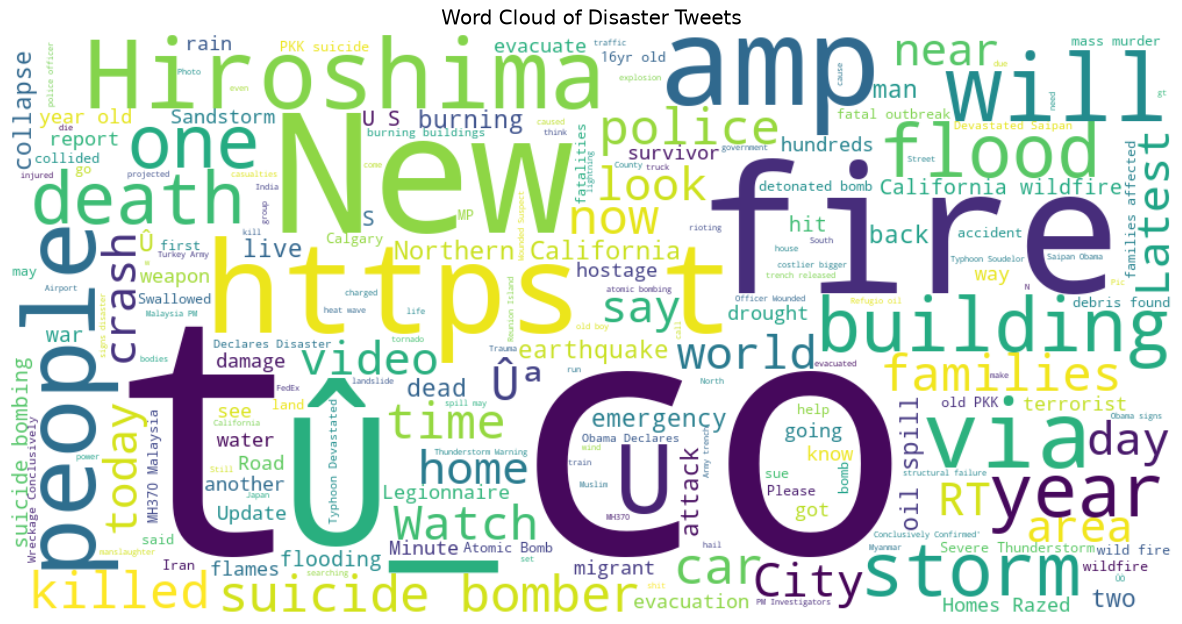

In [26]:
# Import the WordCloud class
from wordcloud import WordCloud

# Combine all disaster tweets into one long string
disaster_text = " ".join(df[df["target"] == 1]["text"].astype(str))

# Create the WordCloud object
wordcloud = WordCloud(
    width=1000,          # Width of the image
    height=500,          # Height of the image
    background_color="white"  # White background
).generate(disaster_text)

# Display the Word Cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide x and y axes
plt.title("Word Cloud of Disaster Tweets")
plt.show()

- The Word Cloud provides a visual representation of the most frequent words.
- Larger words indicate higher frequency.
- Since preprocessing has not yet been applied to all tweets, common stop words are still prominent.
- This highlights the need for text cleaning before feature extraction and model training.

In [27]:
# Import the string module for punctuation characters
import string

# Import English stop words from NLTK
from nltk.corpus import stopwords

# Store stop words in a set for faster lookup
stop_words = set(stopwords.words("english"))

# ----------------------------------------------------
# Function to clean a single tweet
# ----------------------------------------------------
def clean_text(text):
    """
    Cleans a tweet by:
    1. Converting to lowercase
    2. Removing punctuation
    3. Removing stop words

    Parameters:
        text (str): Original tweet

    Returns:
        str: Cleaned tweet
    """

    # Convert everything to lowercase
    text = text.lower()

    # Remove punctuation characters
    for char in string.punctuation:
        text = text.replace(char, "")

    # Split sentence into individual words
    words = text.split()

    # Keep only words that are NOT stop words
    filtered_words = []

    for word in words:
        if word not in stop_words:
            filtered_words.append(word)

    # Convert list back into a sentence
    return " ".join(filtered_words)

In [29]:
# ---------------------------------------------------------
# Apply the clean_text() function to every tweet
# ---------------------------------------------------------

# Create a new column called 'cleaned_text'
# apply() calls clean_text() once for every row in the 'text' column
df["cleaned_text"] = df["text"].apply(clean_text)

# Display the first 5 rows to compare
df[["text", "cleaned_text"]].head(10)

,text,cleaned_text
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,residents asked shelter place notified officers evacuation shelter place orders expected
3,"13,000 people receive #wildfires evacuation orders in California",13000 people receive wildfires evacuation orders california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfires pours school
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy 20 closed directions due lake county fire cafire wildfires
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding streets manitou colorado springs areas
7,I'm on top of the hill and I can see a fire in the woods...,im top hill see fire woods
8,There's an emergency evacuation happening now in the building across the street,theres emergency evacuation happening building across street
9,I'm afraid that the tornado is coming to our area...,im afraid tornado coming area


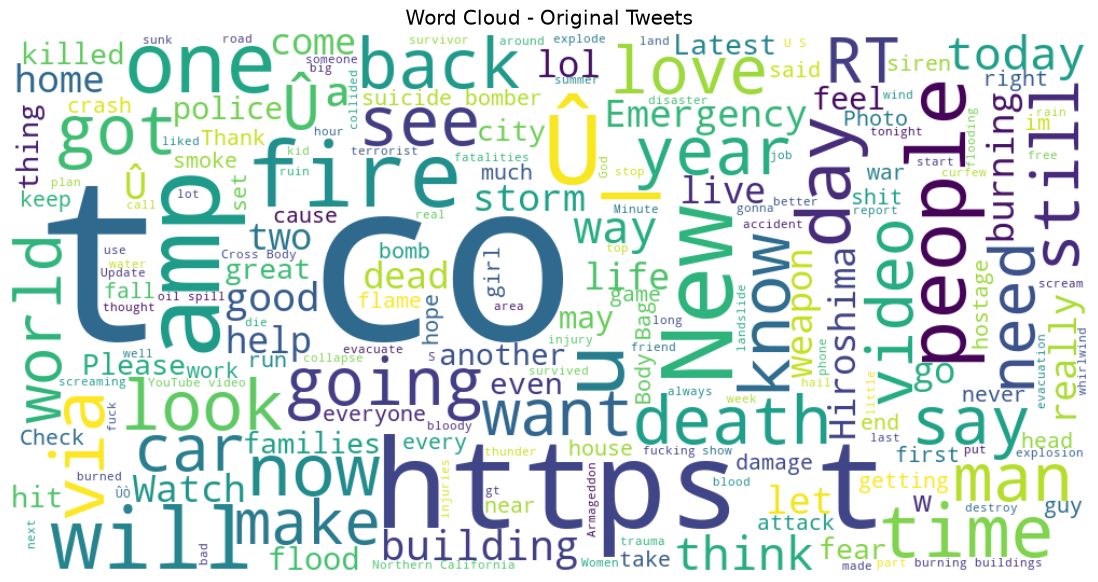

In [30]:
# ==========================================================
# Generate a Word Cloud using the ORIGINAL tweets
# ==========================================================

# Import the WordCloud class
from wordcloud import WordCloud

# Combine all original tweets into one large string
original_text = " ".join(df["text"].astype(str))

# Create the Word Cloud
wordcloud_original = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(original_text)

# Display the Word Cloud
plt.figure(figsize=(15, 7))

plt.imshow(wordcloud_original, interpolation="bilinear")

# Hide axis because they don't provide useful information
plt.axis("off")

plt.title("Word Cloud - Original Tweets")

plt.show()

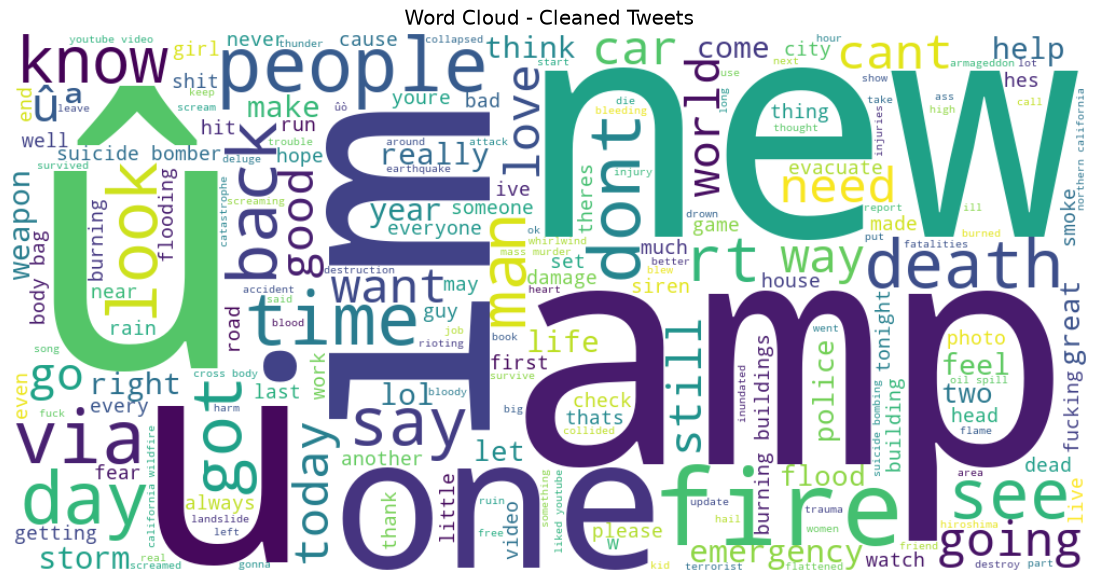

In [31]:
# ==========================================================
# Generate a Word Cloud using CLEANED tweets
# ==========================================================

# Combine all cleaned tweets into one large string
cleaned_text = " ".join(df["cleaned_text"].astype(str))

# Create the Word Cloud
wordcloud_cleaned = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(cleaned_text)

# Display the Word Cloud
plt.figure(figsize=(15, 7))

plt.imshow(wordcloud_cleaned, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud - Cleaned Tweets")

plt.show()

In [32]:
# ==========================================================
# Count the most common words after preprocessing
# ==========================================================

from collections import Counter

# Combine all cleaned tweets
all_words = " ".join(df["cleaned_text"]).split()

# Count word frequencies
word_counts = Counter(all_words)

# Display the top 20 words
word_counts.most_common(20)

[('like', 345),
 ('im', 299),
 ('amp', 298),
 ('fire', 250),
 ('get', 229),
 ('new', 224),
 ('via', 220),
 ('people', 196),
 ('one', 193),
 ('news', 193),
 ('dont', 191),
 ('video', 165),
 ('us', 164),
 ('2', 159),
 ('emergency', 157),
 ('disaster', 152),
 ('police', 140),
 ('would', 131),
 ('still', 129),
 ('body', 124)]

In [35]:
# Download WordNet dictionary (only once)
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...


True

- Lemmatization converts words to their dictionary form (lemma).
- Unlike stemming, the output is usually a valid English word.
- Lemmatization is linguistically more accurate but computationally slower than stemming.
- By default, NLTK assumes words are nouns unless a Part of Speech (POS) is specified.

- Stemming reduces words to their root form using simple rules.
- The resulting stem is not always a valid English word.
- Stemming is fast but may reduce readability and accuracy.

## Stemming vs Lemmatization

| Feature | Stemming | Lemmatization |
|---------|----------|---------------|
| Method | Rule-based | Dictionary + grammar |
| Output | May not be a real word | Usually a valid English word |
| Speed | Faster | Slower |
| Accuracy | Lower | Higher |
| Example | studies → studi | studies → study |

In [ ]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load stop words
stop_words = set(stopwords.words("english"))

# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean a tweet by:
    1. Convert to lowercase
    2. Remove punctuation
    3. Remove stop words
    4. Lemmatize remaining words
    """

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    for char in string.punctuation:
        text = text.replace(char, "")

    # Split into words
    words = text.split()

    cleaned_words = []

    for word in words:

        # Skip stop words
        if word in stop_words:
            continue

        # Lemmatize each remaining word
        cleaned_words.append(
            lemmatizer.lemmatize(word)
        )

    # Join words back into a sentence
    return " ".join(cleaned_words)

In [40]:

# Save cleaned dataset

import os

# Create the processed folder if it doesn't already exist
os.makedirs("../data/processed", exist_ok=True)

# Save the cleaned dataset
df.to_csv(
    "../data/processed/cleaned_train.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
